# 1) Load thedataset1.csvand explore the data, showing size, structureand histograms of numeric data; show the histogram of the frequenciesof the class labels, contained in the “y” column . .

The dataset has size 4800 and has shape (1200, 4)


,0,1,y,2
0,1.589942,2.977770,0,1.953805
1,2.908437,1.837522,1,1.510049
2,3.284091,1.818476,1,3.307287
3,3.148717,2.071991,1,3.452021
4,2.116881,2.133874,0,2.157870


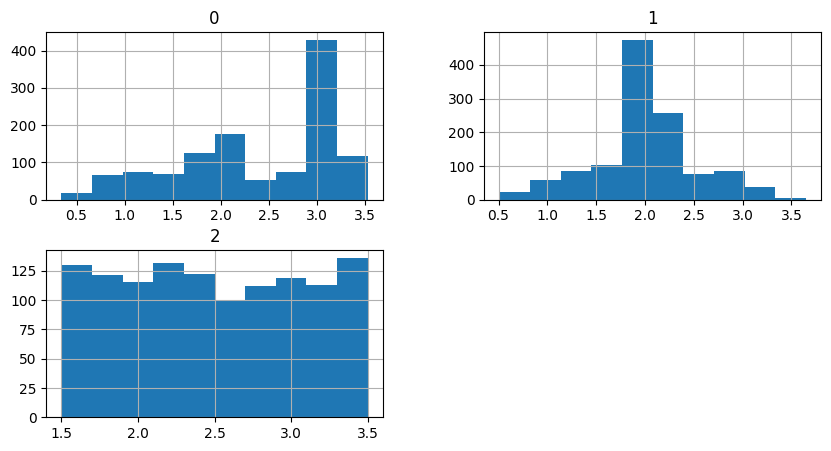

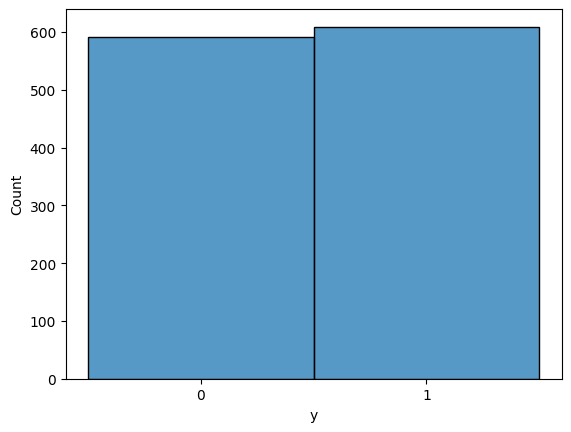

In [62]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

dataset1 = pd.read_csv("./exam_superv.csv")

print(f"The dataset has size {dataset1.size} and has shape {dataset1.shape}")

display(dataset1.head())

numeric_columns = ["0", "1", "2"]
dataset1.hist(column=numeric_columns, figsize=[10,5]);
plt.show()


sns.histplot(data=dataset1["y"], x=dataset1["y"], discrete=True);
plt.xticks(dataset1["y"].unique());

# 2) drop the column “y” and find the best clustering scheme and hyper–parameters able to reproduce the y column (hint: before clustering youcan consider dropping columns with little correlation to “y”; perhapsyou should consider more than one estimator for clustering)

In [63]:
# Low correlation drop
import numpy as np
drop_index = np.argmin(dataset1.corr().drop(index="y").loc[:,"y"]**2) #^2 in order to consider absolute values
df = dataset1.drop(labels=dataset1.columns[drop_index], axis=1)
df.corr()

# Drop y
X = df.drop("y", axis=1)
y = df["y"]

# Definition of estimators
random_state=42
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
models = {
    "km" : {
        "name" : "K-means",
        "estimator" : KMeans(random_state=random_state),
        "params" : [{"n_clusters":[*range(2,11)]}]
    },
    "ac" : {
        "name" : "Agglomerative Clustering",
        "estimator" : AgglomerativeClustering(),
        "params" : [{
            "n_clusters" : [*range(2,11)],
            "linkage" : ["ward", "complete", "average", "single"]
        }]
    },
    "dbs" : {
        "name" : "DBScan",
        "estimator" : DBSCAN(n_jobs=-1),
        "params" : [{
            "min_samples" : [*range(2,10)],
            "eps" : np.arange(0.001,1.001,step=0.001)
        }]
    }
}

# Search for best params
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import adjusted_rand_score
best_score = 0
best_params = None
best_k = None
for k, model in models.items():
    for params in ParameterGrid(model["params"]):
        classfier = model["estimator"].set_params(**params)
        y_pred = classfier.fit_predict(X)
        score = adjusted_rand_score(y, y_pred)
        if score > best_score:
            best_score = score
            best_params = params
            best_k = k
        
# Results
print(f"The best model seems to be {models[best_k]['name']} with params {best_params} and produced an adjusted_random_score of {best_score}")

The best model seems to be Agglomerative Clustering with params {'linkage': 'average', 'n_clusters': 2} and produced an adjusted_random_score of 0.9505838161695588


The accuracy is 0.9875


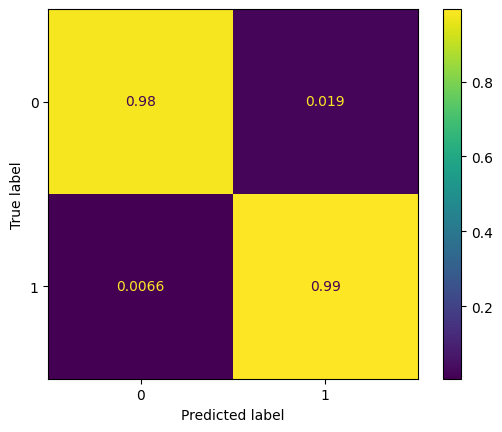

In [64]:
y_pred_best = models[best_k]["estimator"].set_params(**best_params).fit_predict(X)

from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay, confusion_matrix
print(f"The accuracy is {accuracy_score(y, y_pred_best)}")
ConfusionMatrixDisplay(confusion_matrix(y, y_pred_best, normalize="true")).plot();

# 4) apply the same transformations, todataset2.csv, then apply the bestclustering scheme and hyper parameters and plot the data with theassigned labels . 

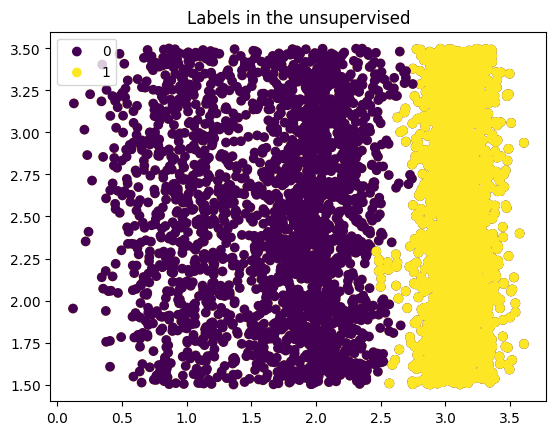

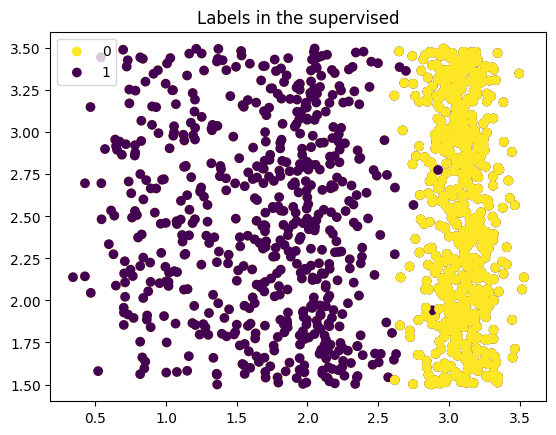

In [68]:
dataset2 = pd.read_csv("./exam_unsuperv.csv")

# Low correlation drop
df_2 = dataset2.drop(labels=dataset2.columns[drop_index], axis=1)
df_2.corr()

# Cluster
y_pred_best = models[best_k]["estimator"].set_params(**best_params).fit_predict(df_2)

# Plot the predicted clusters
import matplotlib.pyplot as plt
for l in np.unique(y_pred_best):
    plt.scatter(x=df_2["0"], y=df_2["2"], c=(y_pred_best==l), label=l)
plt.legend()
plt.title("Labels in the unsupervised")
plt.show()

# Plot the true clusters
for l in np.unique(y):
    plt.scatter(x=df["0"], y=df["2"], c=(y==l), label=l)
plt.legend()
plt.title("Labels in the supervised")
plt.show()